## Diego Emilio Muñiz Ramirez
## 24/02/26
## 621784

Doy mi palabra de que he realizado esta actividad con integridad academica

## Importación y preparación de datos

Se importa la base de datos de propiedades. La variable de salida será is_apartment, una variable binaria que vale 1 si la propiedad es un departamento y 0 si es una casa. Se eliminan las observaciones de tipo store y PH por ser minorías que no forman parte de la clasificación binaria de interés.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, accuracy_score, roc_auc_score, roc_curve
)
from sklearn.preprocessing import StandardScaler

# Cargar datos
df = pd.read_csv('dataset.csv')

# Filtrar solo apartment y house
df = df[df['property_type'].isin(['apartment', 'house'])].copy()

# Crear variable binaria de salida
df['is_apartment'] = (df['property_type'] == 'apartment').astype(int)

# Seleccionar características numéricas relevantes
features = ['price_aprox_usd', 'surface_total_in_m2', 'surface_covered_in_m2',
            'price_usd_per_m2', 'price_per_m2']

df = df[features + ['is_apartment']].dropna()

print(f"Registros tras limpieza: {len(df)}")
print("\nDistribución de la variable de salida:")
print(df['is_apartment'].value_counts())
print("\nPrimeras filas:")
df.head()

Registros tras limpieza: 18053

Distribución de la variable de salida:
is_apartment
1    13108
0     4945
Name: count, dtype: int64

Primeras filas:


,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,is_apartment
0,289775.66,54.0,54.0,5366.215926,101851.85190,1
1,79661.96,80.0,80.0,995.774500,18900.00000,0
2,48822.82,100.0,100.0,488.228200,9266.67000,1
3,337720.36,135.0,135.0,2501.632296,47481.48148,1
4,232663.51,87.0,87.0,2674.293218,50758.62069,1


## 2. Separación entrenamiento / prueba (80/20) con balance de clases

Se usa stratify=y en train_test_split para garantizar que la proporción de clases sea similar en los tres grupos: datos originales, entrenamiento y prueba.

In [ ]:
X = df[features]
y = df['is_apartment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Escalar características
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

def class_proportions(y_series, label):
    props = y_series.value_counts(normalize=True).sort_index()
    print(f"{label}  →  clase 0 (house): {props[0]:.2%}  |  clase 1 (apartment): {props[1]:.2%}")

class_proportions(y,       "Datos originales  ")
class_proportions(y_train, "Entrenamiento     ")
class_proportions(y_test,  "Prueba            ")

print(f"\nTamaño entrenamiento : {len(X_train)}")
print(f"Tamaño prueba        : {len(X_test)}")

Datos originales    →  clase 0 (house): 27.39%  |  clase 1 (apartment): 72.61%
Entrenamiento       →  clase 0 (house): 27.39%  |  clase 1 (apartment): 72.61%
Prueba              →  clase 0 (house): 27.39%  |  clase 1 (apartment): 72.61%

Tamaño entrenamiento : 14442
Tamaño prueba        : 3611


## 3. Validación cruzada sobre los datos de entrenamiento

Se aplica **Stratified K-Fold** con k=10 para estimar la exactitud del modelo de regresión logística en los datos de entrenamiento, sin tocar el conjunto de prueba.

Exactitud por fold: [0.7779 0.7612 0.7611 0.7548 0.7715 0.7645 0.7576 0.759  0.7715 0.7625]

Exactitud media  : 0.7642
Desviación estándar: 0.0069


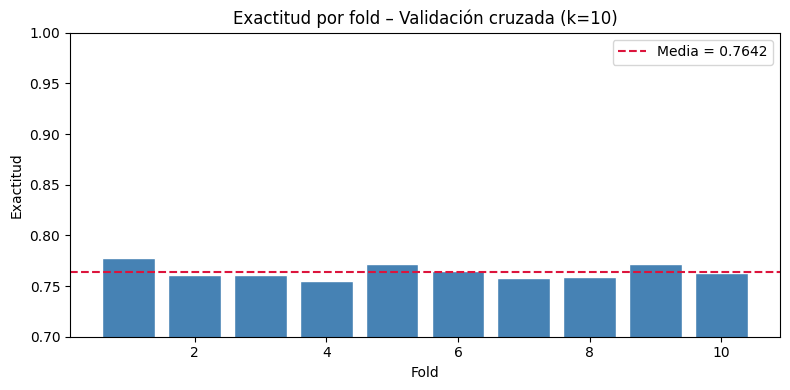

In [ ]:
logistic_model_cv = LogisticRegression(max_iter=1000, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    logistic_model_cv, X_train_sc, y_train,
    cv=skf, scoring='accuracy'
)

print("Exactitud por fold:", np.round(cv_scores, 4))
print(f"\nExactitud media  : {cv_scores.mean():.4f}")
print(f"Desviación estándar: {cv_scores.std():.4f}")

# Gráfica de resultados por fold
plt.figure(figsize=(8, 4))
plt.bar(range(1, 11), cv_scores, color='steelblue', edgecolor='white')
plt.axhline(cv_scores.mean(), color='crimson', linestyle='--', label=f'Media = {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('Exactitud')
plt.title('Exactitud por fold – Validación cruzada (k=10)')
plt.ylim(0.7, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Entrenamiento final y evaluación con distintos umbrales

Se entrena el modelo sobre **todos** los datos de entrenamiento y se generan probabilidades para el conjunto de prueba. Se evalúa la exactitud, sensibilidad y especificidad para tres umbrales: 0.3, 0.5 y 0.7.


 Umbral: Bajo  (0.30)
 Matriz de confusión:
[[  94  895]
 [  23 2599]]
 Exactitud    : 0.7458
 Sensibilidad : 0.9912
 Especificidad: 0.0950

 Umbral: Normal (0.50)
 Matriz de confusión:
[[ 166  823]
 [  42 2580]]
 Exactitud    : 0.7605
 Sensibilidad : 0.9840
 Especificidad: 0.1678

 Umbral: Alto  (0.70)
 Matriz de confusión:
[[ 698  291]
 [ 587 2035]]
 Exactitud    : 0.7569
 Sensibilidad : 0.7761
 Especificidad: 0.7058


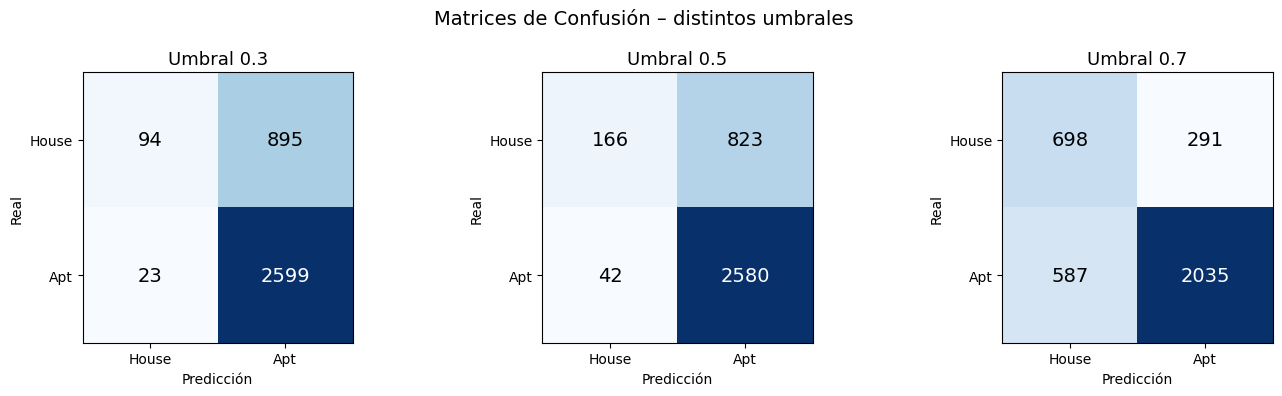

In [ ]:
# Entrenar modelo final
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_sc, y_train)

# Vector de probabilidades (clase 1 = apartment)
y_proba = model.predict_proba(X_test_sc)[:, 1]

def evaluate_threshold(y_true, y_proba, threshold, label):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy    = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Recall / TPR
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
    print(f"\n{'='*40}")
    print(f" Umbral: {label}")
    print(f"{'='*40}")
    print(f" Matriz de confusión:\n{cm}")
    print(f" Exactitud    : {accuracy:.4f}")
    print(f" Sensibilidad : {sensitivity:.4f}")
    print(f" Especificidad: {specificity:.4f}")
    return cm

thresholds = [(0.3, 'Bajo  (0.30)'), (0.5, 'Normal (0.50)'), (0.7, 'Alto  (0.70)')]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (thr, label) in zip(axes, thresholds):
    cm = evaluate_threshold(y_test, y_proba, thr, label)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f'Umbral {thr}', fontsize=13)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['House', 'Apt']); ax.set_yticklabels(['House', 'Apt'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)

plt.suptitle('Matrices de Confusión – distintos umbrales', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Curva ROC y AUC

La curva ROC ilustra el trade-off entre la tasa de verdaderos positivos (sensibilidad) y la tasa de falsos positivos (1 – especificidad) para todos los umbrales posibles. El **AUC** (Área bajo la curva) resume el rendimiento global del modelo: un valor de 1.0 indica clasificación perfecta, 0.5 indica un modelo aleatorio.

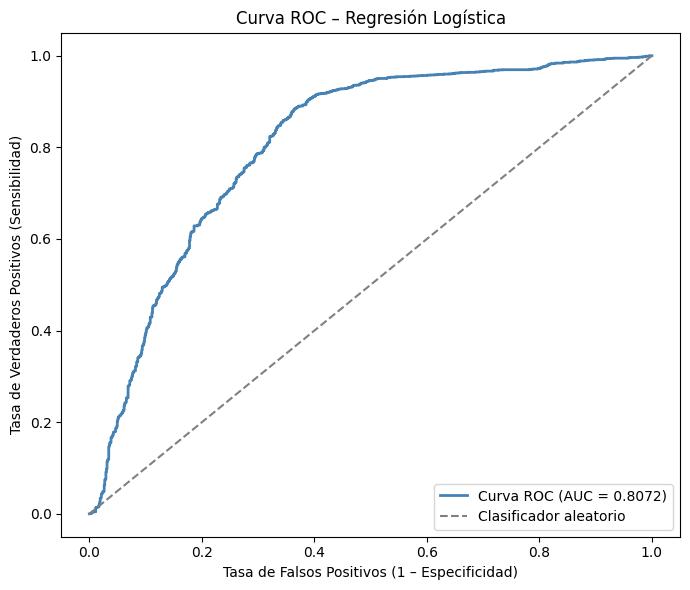

AUC = 0.8072


In [ ]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'Curva ROC (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos (1 – Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC – Regresión Logística')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"AUC = {auc_score:.4f}")

## 6. Interpretación del modelo – coeficientes

Los coeficientes del modelo de regresión logística indican el cambio en el **log-odds** de que una propiedad sea un departamento por cada unidad de aumento en la característica correspondiente (ya estandarizadas). Un coeficiente **positivo** implica que incrementar esa variable aumenta la probabilidad de ser departamento; un coeficiente **negativo** la disminuye.

Intercepto: 1.1267

       Característica  Coeficiente  Odds Ratio
     price_usd_per_m2     2.751483   15.665841
  surface_total_in_m2     1.371226    3.940180
         price_per_m2    -0.650472    0.521799
surface_covered_in_m2    -1.343451    0.260944
      price_aprox_usd    -1.726432    0.177918


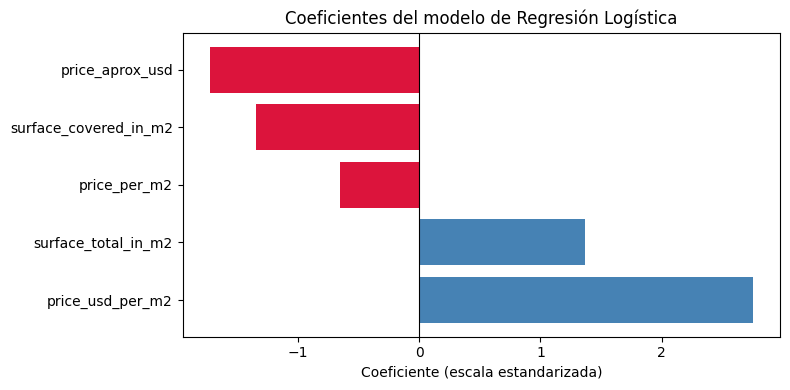

In [ ]:
coef_df = pd.DataFrame({
    'Característica': features,
    'Coeficiente': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0])
}).sort_values('Coeficiente', ascending=False)

print("Intercepto:", round(model.intercept_[0], 4))
print()
print(coef_df.to_string(index=False))

# Gráfica de coeficientes
colors = ['steelblue' if c > 0 else 'crimson' for c in coef_df['Coeficiente']]
plt.figure(figsize=(8, 4))
plt.barh(coef_df['Característica'], coef_df['Coeficiente'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente (escala estandarizada)')
plt.title('Coeficientes del modelo de Regresión Logística')
plt.tight_layout()
plt.show()

### Interpretación textual de los coeficientes

| Característica | Coef. (aprox.) | Interpretación |
|---|---|---|
| price_usd_per_m2 | **+2.75** | Coeficiente positivo más grande. A mayor precio por m², mayor probabilidad de ser departamento. Los departamentos en zonas urbanas densas tienen precios por metro cuadrado más elevados. |
| surface_total_in_m2 | **+1.37** | Positivo: al controlar por las demás variables, propiedades con mayor superficie total también podrían ser departamentos grandes; sin embargo, su efecto aislado es moderado. |
| surface_covered_in_m2 | **−1.34** | Negativo y de magnitud similar: mayor superficie cubierta relativa (casas con muchos metros techados) reduce la probabilidad de ser departamento. |
| price_per_m2 | **−0.65** | Negativo leve. Combinado con price_usd_per_m2, ayuda a capturar diferencias de escala entre monedas/unidades. |
| price_aprox_usd | **−1.73** | Negativo: propiedades con precio total alto en USD tienden a ser casas (mayor superficie a precio absoluto más elevado). |

> **Conclusión general:** El predictor más influyente es el precio por metro cuadrado en USD (coeficiente +2.75): los departamentos se concentran en zonas de alta densidad urbana con mayor valor por metro. En sentido contrario, un precio total alto en USD reduce la probabilidad de ser departamento, pues las casas tienden a ser más grandes y costosas en términos absolutos. El modelo alcanza una exactitud de ~76% en validación cruzada y un AUC de ~0.81, lo que indica un buen poder discriminativo.